In [30]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import numpy as np

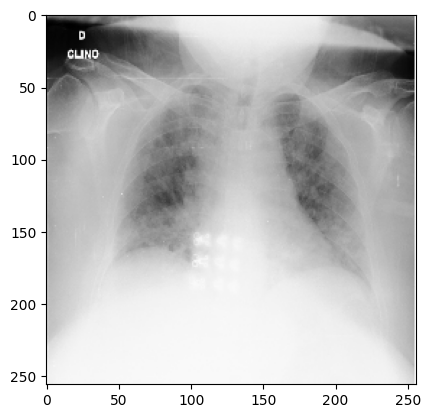

In [31]:
image = cv2.imread("data/COVID/COVID.png", cv2.IMREAD_GRAYSCALE)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.show()

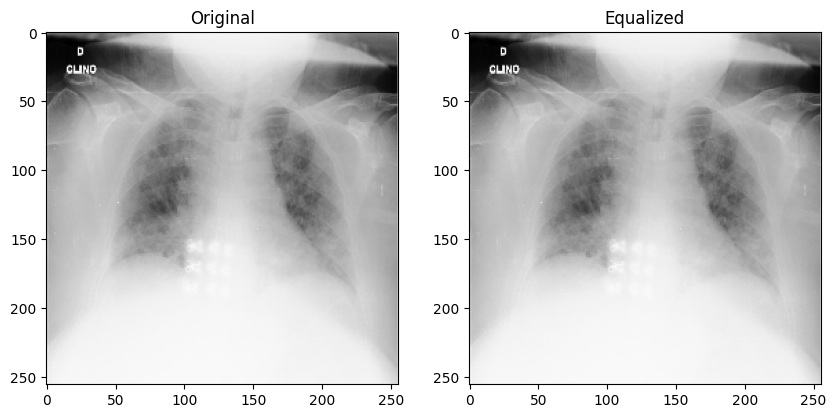

In [ ]:
# Contrast Enhancement
equalized_image = cv2.equalizeHist(image)

equalized_image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Original")

axes[1].imshow(equalized_image_rgb)
axes[1].set_title("Equalized")

plt.show()

It shows the lungs structures a bit more clearly

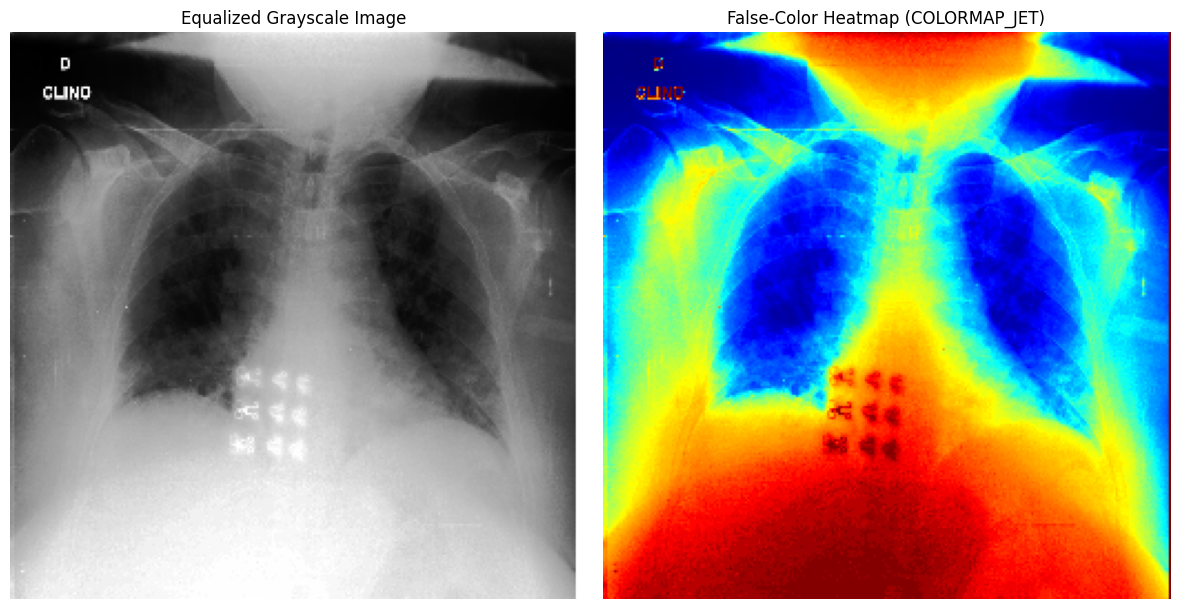

In [33]:
# Color Mapping
heatmap_bgr = cv2.applyColorMap(equalized_image, cv2.COLORMAP_JET)

heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(equalized_image, cmap="gray")
axes[0].set_title("Equalized Grayscale Image", fontsize=12)
axes[0].axis("off")

axes[1].imshow(heatmap_rgb)
axes[1].axis("off")
axes[1].set_title("False-Color Heatmap (COLORMAP_JET)", fontsize=12)

plt.tight_layout()
plt.show()

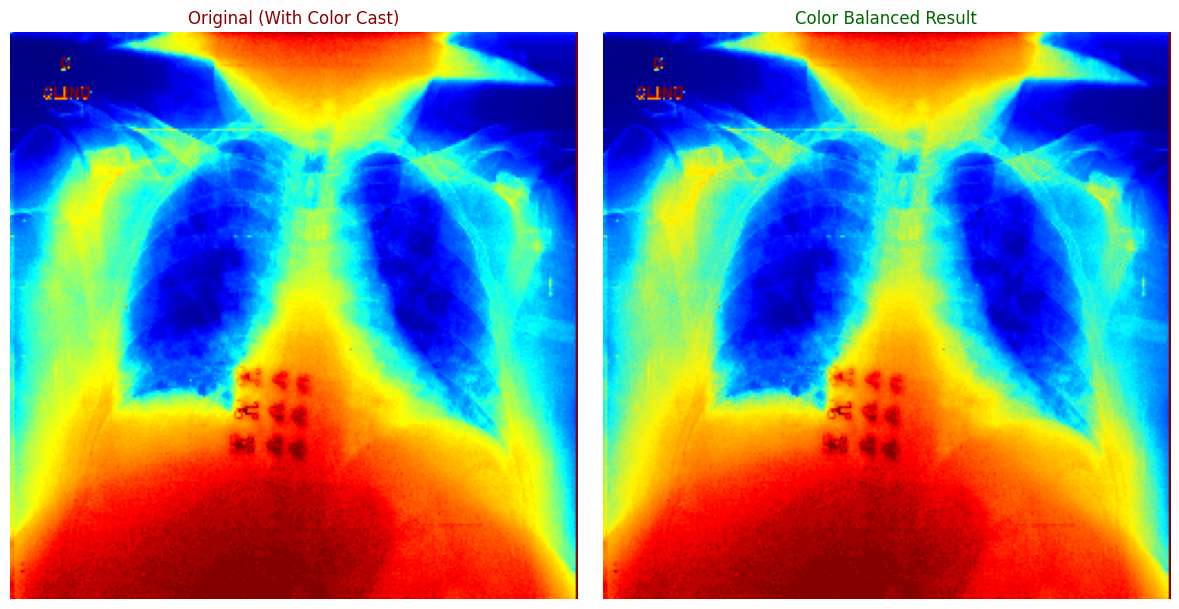

In [34]:
# Color Balance
b, g, r = cv2.split(heatmap_bgr)

mean_b = np.mean(b)
mean_g = np.mean(g)
mean_r = np.mean(r)

mean_gray = (mean_b + mean_g + mean_r) / 3.0

# Calculate the scaling factors for each channel to neutralize the cast
# Avoid division by zero by ensuring means are not zero
scale_b = mean_gray / (mean_b if mean_b > 0 else 1)
scale_g = mean_gray / (mean_g if mean_g > 0 else 1)
scale_r = mean_gray / (mean_r if mean_r > 0 else 1)

# Apply the mathematical shift by scaling each channel independently
# Convert to float to avoid overflow errors during multiplication
b_balanced = np.clip(b * scale_b, 0, 255).astype(np.uint8)
g_balanced = np.clip(g * scale_g, 0, 255).astype(np.uint8)
r_balanced = np.clip(r * scale_r, 0, 255).astype(np.uint8)

# Merge the balanced channels back into a single BGR image
balanced_bgr = cv2.merge([b_balanced, g_balanced, r_balanced])

# 3. Convert both images to RGB format for accurate Matplotlib display
orig_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)
balanced_rgb = cv2.cvtColor(balanced_bgr, cv2.COLOR_BGR2RGB)

# 4. Display the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(orig_rgb)
axes[0].set_title("Original (With Color Cast)", fontsize=12, color="darkred")
axes[0].axis("off")

axes[1].imshow(balanced_rgb)
axes[1].set_title("Color Balanced Result", fontsize=12, color="darkgreen")
axes[1].axis("off")

plt.tight_layout()
plt.show()

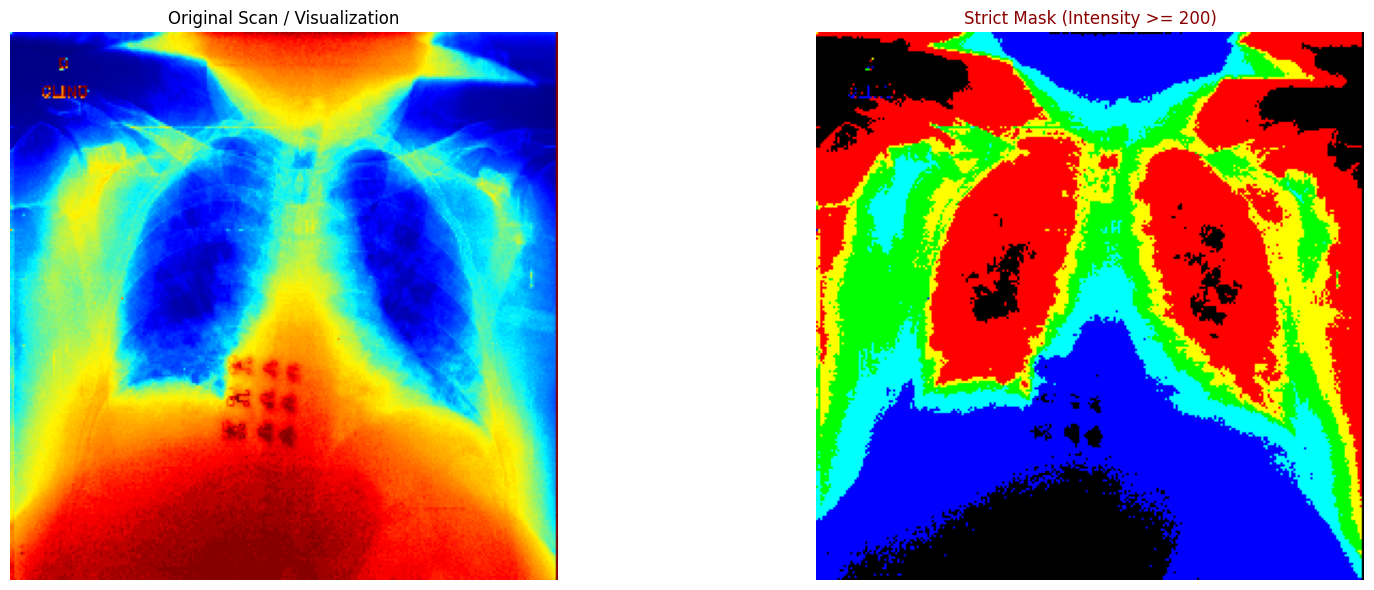

In [35]:
# Color Filtering (Threshold)
threshold_value = 200
max_value = 255
ret, dense_tissue_mask = cv2.threshold(
    balanced_bgr, threshold_value, max_value, cv2.THRESH_BINARY
)

# 4. Display the results side-by-side using Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Original input scan
axes[0].imshow(balanced_rgb, cmap="gray")
axes[0].set_title("Original Scan / Visualization", fontsize=12)
axes[0].axis("off")

# Plot 2: Binary mask isolating dense tissue
axes[1].imshow(dense_tissue_mask, cmap="gray")
axes[1].set_title(
    f"Strict Mask (Intensity >= {threshold_value})", fontsize=12, color="darkred"
)
axes[1].axis("off")


plt.tight_layout()
plt.show()

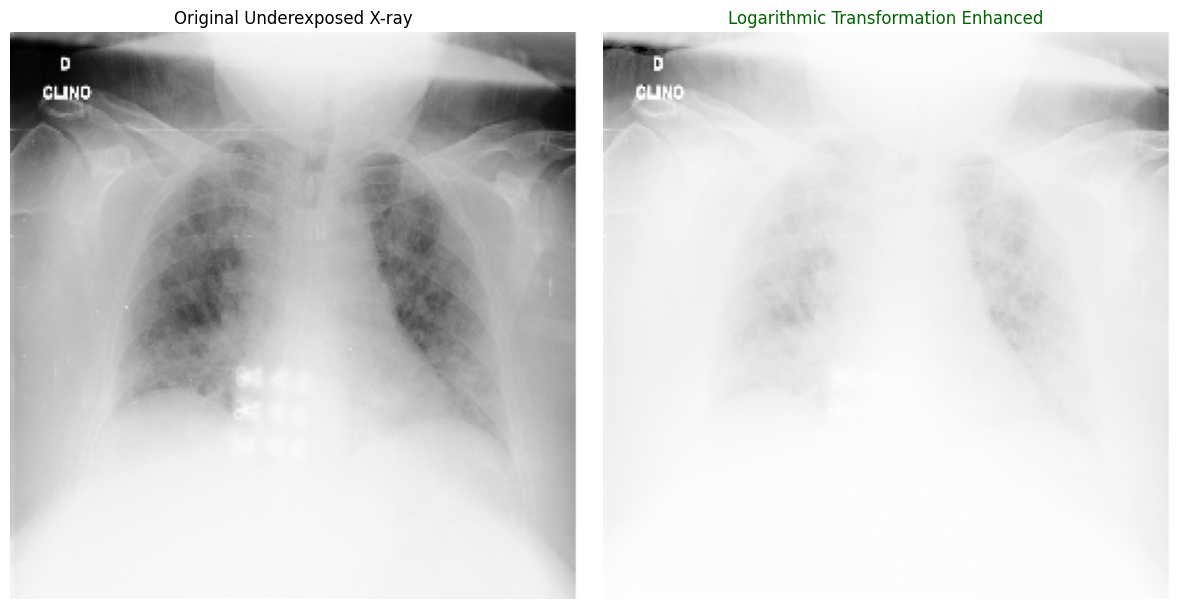

In [36]:
# Logarithmic Transformation
image_float = image.astype(np.float32)

max_val = np.max(image_float)
c = 255 / np.log(1 + max_val)

log_transformed = c * np.log(1 + image_float)

log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Underexposed X-ray", fontsize=12)
axes[0].axis("off")

axes[1].imshow(log_transformed, cmap="gray")
axes[1].set_title("Logarithmic Transformation Enhanced", fontsize=12, color="darkgreen")
axes[1].axis("off")

plt.tight_layout()
plt.show()

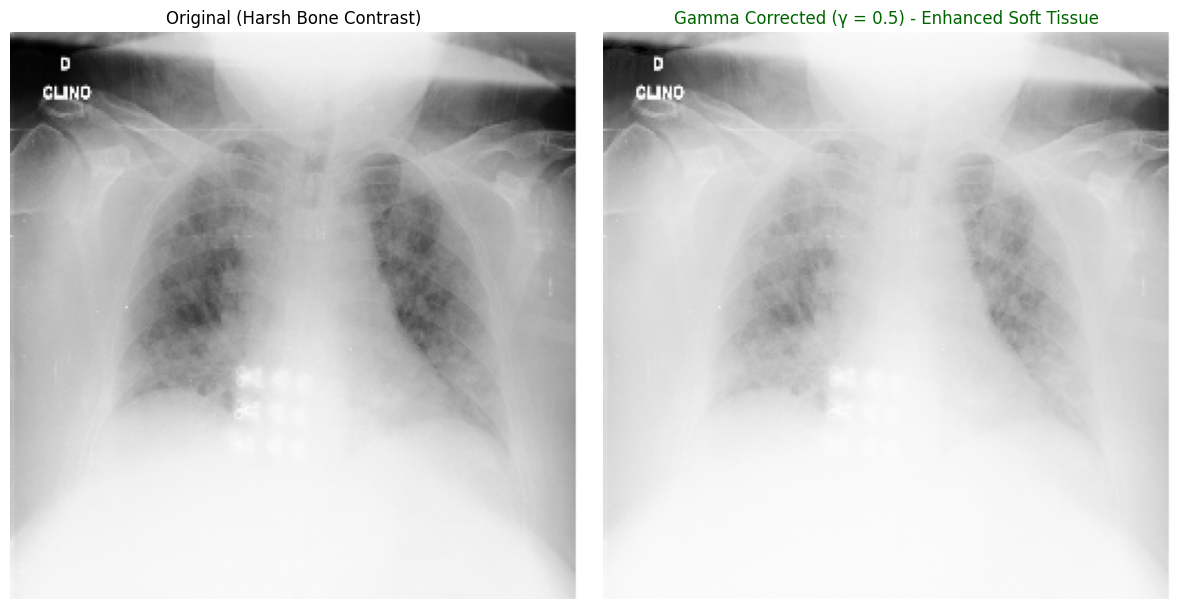

In [37]:
# Power Law Transformation (Gamma)

img_normalized = image / 255.0

# 3. Define a fractional gamma value (gamma < 1.0)
# Values between 0.4 and 0.7 are ideal for expanding dark/midtone details
gamma = 0.5

# 4. Apply the power-law transformation formula: s = c * (r ^ gamma)
# Since the image is normalized to 1.0 max, the scaling constant 'c' is simply 1.0
gamma_corrected = np.power(img_normalized, gamma)

# 5. Scale the float image back up to the standard 8-bit range [0, 255]
gamma_corrected = (gamma_corrected * 255).astype(np.uint8)

# 6. Display the original and the tissue-enhanced result side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original (Harsh Bone Contrast)", fontsize=12)
axes[0].axis("off")

axes[1].imshow(gamma_corrected, cmap="gray")
axes[1].set_title(
    f"Gamma Corrected (\u03B3 = {gamma}) - Enhanced Soft Tissue",
    fontsize=12,
    color="darkgreen",
)
axes[1].axis("off")

plt.tight_layout()
plt.show()